# 화재 발생 특성에 따른 인명피해 예측 분석 (최종)

## 가설
**시도, 발화요인, 화재 발생 장소, 발생 월·시간·요일에 따라 인명피해 발생 확률이 달라질 것이다**

- 종속변수(y): 인명피해_발생여부 (0/1)
- 독립변수(X): 시도, 발화요인소분류, 장소대분류, 발생_월, 발생_시간, 발생_요일


- 계절/시간대를 별도 구간으로 나누지 않고, 발생_월·발생_시간·발생_요일은 숫자 그대로 사용 (스케일링만 적용)
- 수치형 컬럼은 지금 결측치가 없지만, 나중에 데이터가 추가될 경우를 대비해 중앙값 대체(SimpleImputer)를 안전장치로 유지
- predict_proba 기준값(threshold)은 0.5 대신 0.3 사용 (인명피해는 놓치면 안 되는 문제라 recall 우선)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False


### 1. 데이터 불러오기

In [2]:
df = pd.read_csv('fire.csv', encoding='utf-8-sig')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 191510 entries, 0 to 191509
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   시도         191510 non-null  str  
 1   화재유형       191510 non-null  str  
 2   발화요인대분류    191510 non-null  str  
 3   발화요인소분류    191510 non-null  str  
 4   장소대분류      191510 non-null  str  
 5   인명피해_발생여부  191510 non-null  int64
 6   발생_월       191510 non-null  int64
 7   발생_시간      191510 non-null  int64
 8   발생_요일      191510 non-null  int64
dtypes: int64(4), str(5)
memory usage: 26.5 MB


In [3]:
df.head()

,시도,화재유형,발화요인대분류,발화요인소분류,장소대분류,인명피해_발생여부,발생_월,발생_시간,발생_요일
0,전북특별자치도,"건축,구조물",부주의,기타(부주의),생활서비스,0,1,0,2
1,서울특별시,기타(쓰레기 화재등),부주의,담배꽁초,기타,0,1,0,2
2,경상북도,기타(쓰레기 화재등),부주의,담배꽁초,기타,0,1,0,2
3,충청북도,"자동차,철도차량",기계적 요인,"과열, 과부하","자동차,철도차량",0,1,0,2
4,부산광역시,"자동차,철도차량",미상,미상,"자동차,철도차량",0,1,0,2


### 2. 입력(피처)과 정답(타겟) 분리

In [4]:
FEATURES = ['시도', '발화요인소분류', '장소대분류', '발생_월', '발생_시간', '발생_요일']
TARGET = '인명피해_발생여부'

# 숫자형 : 중앙값 대체(안전장치) + 스케일링
NUMERIC = ['발생_월', '발생_시간', '발생_요일']
# 범주형 : 결측치 최빈값 대체 + 원-핫 인코딩
CATEGORICAL = ['시도', '발화요인소분류', '장소대분류']

X = df[FEATURES]
y = df[TARGET]

X.head()


,시도,발화요인소분류,장소대분류,발생_월,발생_시간,발생_요일
0,전북특별자치도,기타(부주의),생활서비스,1,0,2
1,서울특별시,담배꽁초,기타,1,0,2
2,경상북도,담배꽁초,기타,1,0,2
3,충청북도,"과열, 과부하","자동차,철도차량",1,0,2
4,부산광역시,미상,"자동차,철도차량",1,0,2


In [5]:
y.value_counts(normalize=True)

인명피해_발생여부
0    0.955543
1    0.044457
Name: proportion, dtype: float64

### 3. 훈련 데이터와 검증(테스트) 데이터 나누기

In [ ]:
# 75:25 (test_size=0.25), 불균형 타겟이라 stratify=y로 비율 유지
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_valid.shape


((143632, 6), (47878, 6))

### 4. 전처리 파이프라인 구성

- 숫자형(발생_월·시간·요일): `SimpleImputer(strategy='median')`로 결측치 대비 + `StandardScaler`로 스케일링
  - 지금 데이터엔 결측치가 없어 실제로는 동작하지 않지만, 나중에 데이터가 추가될 경우를 대비한 안전장치
- 범주형(시도·발화요인·장소): 결측치 최빈값 대체 + `OneHotEncoder`


In [7]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # 결측치 없어도 안전장치로 유지
    ('scaler', StandardScaler())
])

category_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipe, NUMERIC),
    ('category', category_pipe, CATEGORICAL)
])


### 5. 모델 정의 및 파이프라인 결합

In [8]:
model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # 인명피해(1)가 적은 불균형 데이터 보정
    min_samples_leaf=3,        # 과적합 방지
    random_state=42
)

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', model)
])

pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

### 6. 예측 및 Threshold 적용

- 기본값 0.5 대신 **0.3**을 기준으로 사용 (recall 우선)


In [9]:
proba = pipeline.predict_proba(X_valid)[:, 1]   # 인명피해 발생 확률

THRESHOLD = 0.3
pred = (proba >= THRESHOLD).astype(int)
pred[:10]


array([0, 0, 1, 0, 0, 0, 1, 0, 0, 1])

### 7. 평가지표

In [10]:
report = classification_report(y_valid, pred, output_dict=True, zero_division=0)
roc = roc_auc_score(y_valid, proba)
cm = confusion_matrix(y_valid, pred)

print('ROC-AUC   :', round(roc, 4))
print('Recall(1) :', round(report['1']['recall'], 4))
print('Precision(1):', round(report['1']['precision'], 4))
print('F1(1)     :', round(report['1']['f1-score'], 4))
print()
print('혼동행렬(Confusion Matrix):')
print(cm)


ROC-AUC   : 0.7577
Recall(1) : 0.6022
Precision(1): 0.1041
F1(1)     : 0.1775

혼동행렬(Confusion Matrix):
[[34717 11032]
 [  847  1282]]


### 8. 어떤 특성이 중요했는지 확인

In [11]:
importances = pipeline.named_steps['model'].feature_importances_
feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()

imp_df = pd.DataFrame({'변수': feature_names, '중요도': importances})
imp_df['변수'] = imp_df['변수'].str.replace('numeric__', '', regex=False)\
                                .str.replace('category__', '', regex=False)
imp_df = imp_df.sort_values('중요도', ascending=False)
imp_df.head(15)


,변수,중요도
1,발생_시간,0.174410
0,발생_월,0.140582
2,발생_요일,0.111163
81,장소대분류_주거,0.050056
70,장소대분류_기타,0.039107
20,발화요인소분류_가스누출(폭발),0.022603
39,발화요인소분류_미상,0.022293
42,발화요인소분류_방화,0.021341
37,발화요인소분류_담배꽁초,0.020595
43,발화요인소분류_방화의심,0.017935


### 9. 결과 시각화 (혼동행렬 + 특성중요도)

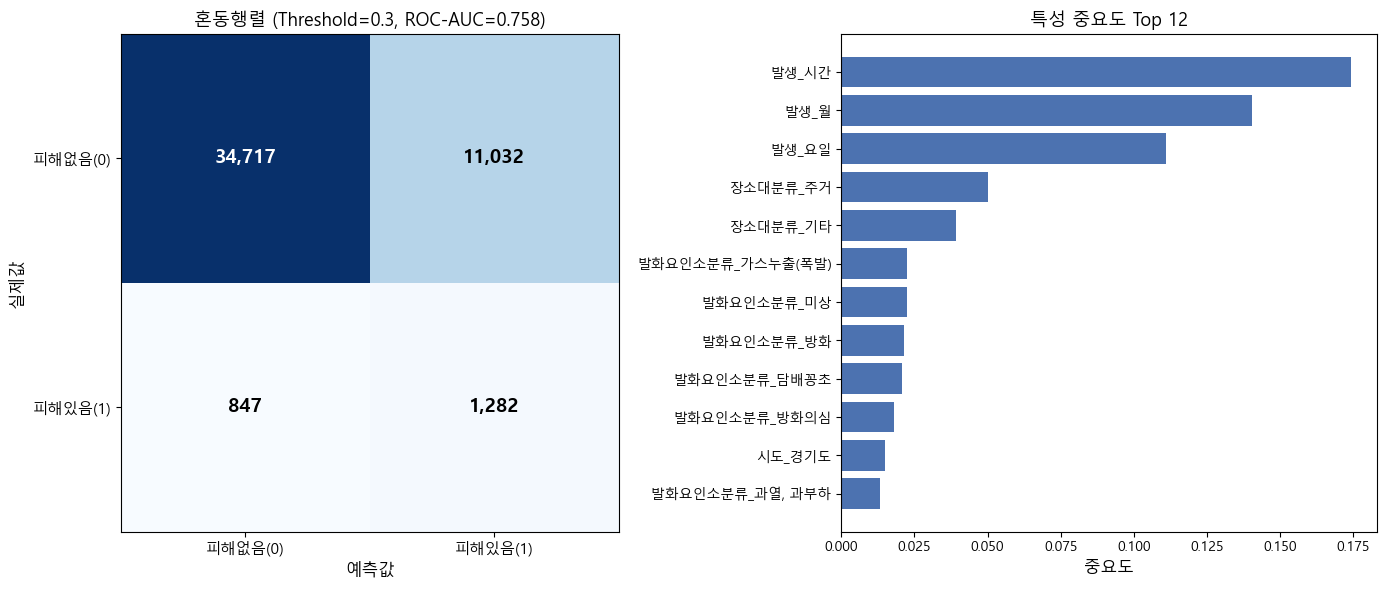

In [15]:
top_n = 12
top = imp_df.head(top_n).sort_values('중요도')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
labels = ['피해없음(0)', '피해있음(1)']
ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('예측값', fontsize=12)
ax.set_ylabel('실제값', fontsize=12)
ax.set_title(f'혼동행렬 (Threshold={THRESHOLD}, ROC-AUC={roc:.3f})', fontsize=13)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black',
                 fontsize=14, fontweight='bold')

ax2 = axes[1]
ax2.barh(top['변수'], top['중요도'], color='#4C72B0')
ax2.set_title(f'특성 중요도 Top {top_n}', fontsize=13)
ax2.set_xlabel('중요도', fontsize=12)

plt.tight_layout()
plt.show()


## 10. 해석 및 결론

- ROC-AUC 0.758, Threshold 0.3 기준 Recall 0.60, Precision 0.10
- 특성중요도 1~3위가 발생_시간, 발생_월, 발생_요일로 나타나, **"언제(시간·월·요일)" 화재가 났는지가 인명피해 여부에 가장 큰 영향을 미침**
- 그다음으로 장소대분류_주거, 장소대분류_기타가 이어져, 발화요인 자체보다 시간·장소 요인이 더 중요하게 나타남
- **최종 결론**: 인명피해는 발화요인보다 발생 시점(월·시간·요일)과 장소에 더 크게 좌우되는 것으로 확인됨
